<a href="https://colab.research.google.com/github/gauravprajapati9210/Machine-Learning-Projects/blob/main/Gold_Price_Prediction_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing depandancies
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

Data Collection and Processing

In [2]:
# loading csv data to a pandas DataFrame

gold_data= pd.read_csv("/content/gld_price_data.csv")

first 5 rows


In [4]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


Checking null values

In [7]:
gold_data.isnull().sum()


,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


last 5 rows

In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
# number of rows and columns
gold_data.shape

(2290, 6)

In [10]:
# getting score basic information about data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [12]:
# Getting the Satatistical measures of the dataset
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


find the Co- relation :
1. Positive Correlation

2.Negative Correlations


In [19]:
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

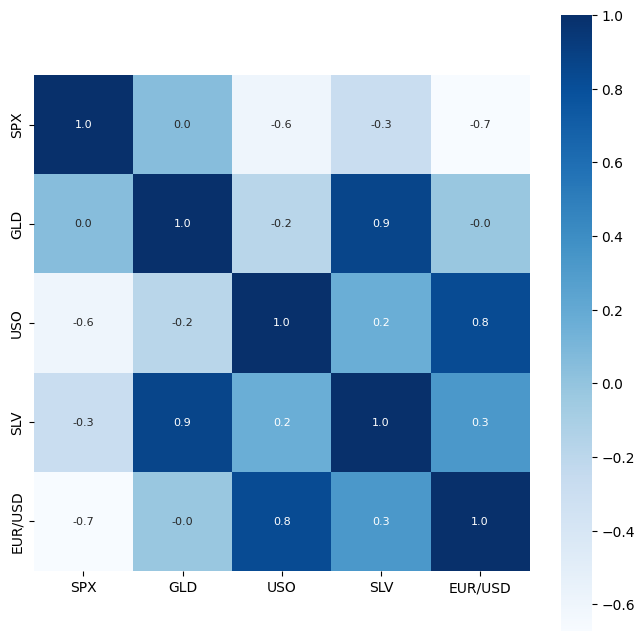

In [29]:
# constructiong a heatmap to understand the correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [30]:
# This cell extracts and prints the correlation values specifically for the 'GLD' price,
# showing its relationship with other financial indicators in the dataset.
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_5362/1588178145.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color = 'Gold')


<Axes: xlabel='GLD', ylabel='Density'>

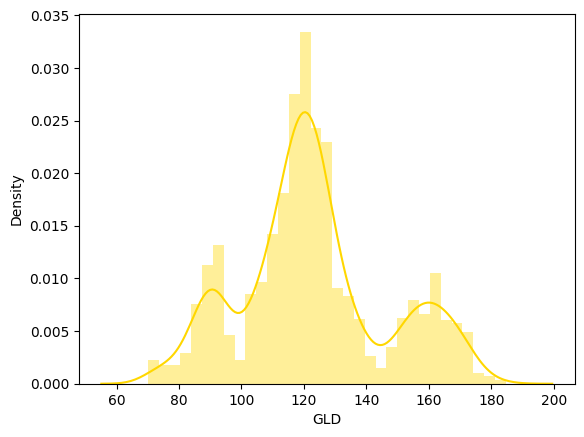

In [32]:
# checking the distribution of the GLD price

sns.distplot(gold_data['GLD'],color = 'Gold')

Spliting the Features and Target


In [33]:
X = gold_data.drop(['Date','GLD'],axis = 1)

In [34]:
Y = gold_data['GLD']

Spliting into testing data and training dataset


In [38]:
# training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model traning

In [39]:
model = RandomForestRegressor(n_estimators=100)

In [40]:
# training the model
model.fit(X_train, Y_train)

RandomForestRegressor()

Model Evaluation


In [41]:
# prediction on test data
test_data_prediction = model.predict(X_test)

In [42]:
print(test_data_prediction)

[168.59349921  81.88709999 116.12890007 127.66600078 120.50920133
 154.79199763 150.12579876 126.07330087 117.4946988  125.87510086
 116.51870115 172.16380112 141.18819801 167.71509822 115.10600018
 117.78970002 137.85540268 170.30470142 159.12040359 156.92679921
 155.15060007 125.40510025 176.21010003 157.1717035  125.2711006
  93.78209969  77.14890036 121.02430029 119.12879974 167.57189898
  88.12940069 125.24280007  91.10200092 117.5379007  121.12179919
 136.59290076 115.52370113 115.40310042 145.86489941 107.32650071
 104.20380256  87.23259767 126.5197007  118.12829961 153.11959901
 119.65890016 108.43439959 107.91199786  93.30370078 127.08719795
  74.65980049 113.65589905 121.41639993 111.25079941 118.97359904
 120.84189914 159.52650076 169.14360139 146.81989696  85.88649844
  94.34920025  86.94039869  90.58040015 118.82720084 126.4436004
 127.42469927 169.6202999  122.24629931 117.55449906  98.56590048
 168.73070115 143.5275991  131.70440318 121.21260238 121.1506997
 119.66180052

In [43]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)


R squared error :  0.9893624547766667


Compare the actual values and predicted values in plot.


In [44]:
Y_test = list(Y_test)

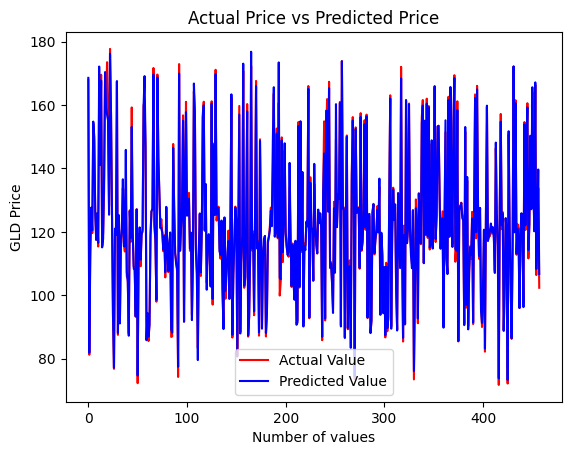

In [50]:
plt.plot(Y_test, color='red', label = 'Actual Value')
plt.plot(test_data_prediction, color='blue', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()